<a href="https://www.kaggle.com/code/greatcool/new-code-py?scriptVersionId=345636210" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import pandas as pd

# Automatically locate the CSV file path in Kaggle's input folder
file_path = ""
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(root, file)
            break

df = pd.read_csv(file_path)
print(f"Loaded successfully from: {file_path}")

Loaded successfully from: /kaggle/input/datasets/greatcool/financial-transactions-and-fraud-detection-dataset/synthetic_financial_transactions.csv


--- Dataset Shape ---
Rows: 10000, Columns: 11

--- Missing Values ---
transaction_id    0
timestamp         0
user_id           0
account_type      0
category          0
amount            0
currency          0
payment_method    0
device_type       0
risk_score        0
is_fraud          0
dtype: int64

--- Target Distribution (%) ---
is_fraud
0    98.74
1     1.26
Name: proportion, dtype: float64


/tmp/ipykernel_16/2961731676.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_fraud', ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_16/2961731676.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Legitimate', 'Fraudulent'])
/tmp/ipykernel_16/2961731676.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y='risk_score', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_16/2961731676.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_x

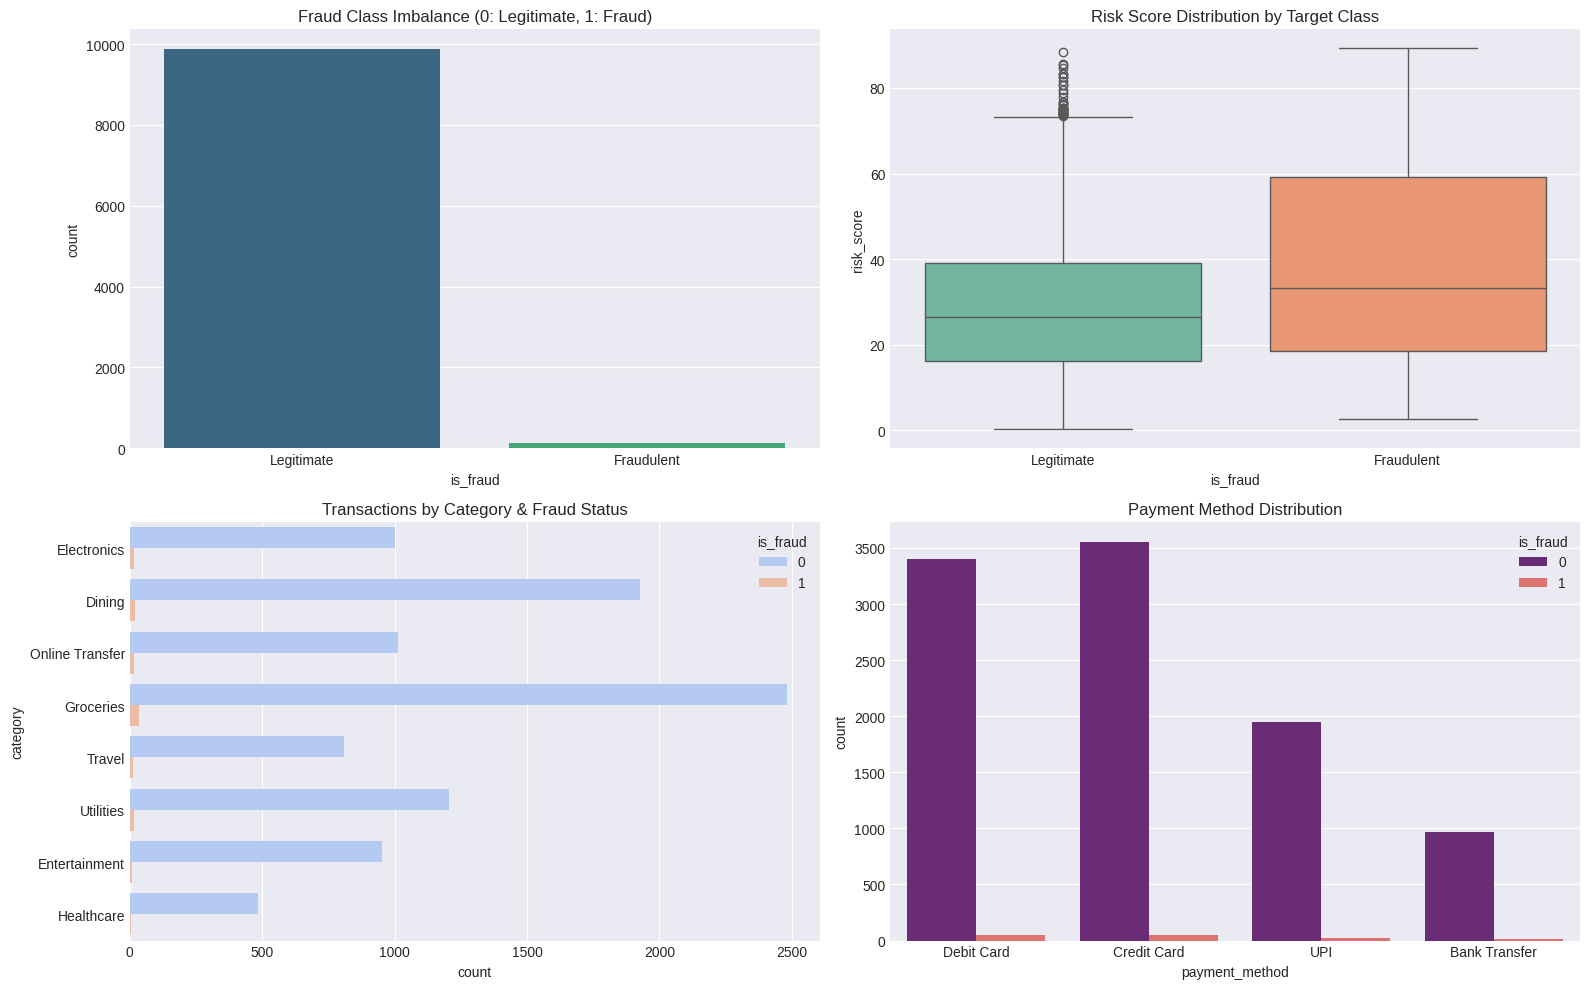

--- Baseline Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1975
           1       0.00      0.00      0.00        25

    accuracy                           0.99      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.98      0.99      0.98      2000

ROC-AUC Score: 0.5964


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Updated hardcoded path from your working directory
file_path = '/kaggle/input/datasets/greatcool/financial-transactions-and-fraud-detection-dataset/synthetic_financial_transactions.csv'

df = pd.read_csv(file_path)

# Dataset basic inspection
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Target Distribution (%) ---")
print(df['is_fraud'].value_counts(normalize=True) * 100)

df.head()


plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Target Imbalance
sns.countplot(data=df, x='is_fraud', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Fraud Class Imbalance (0: Legitimate, 1: Fraud)')
axes[0, 0].set_xticklabels(['Legitimate', 'Fraudulent'])

# 2. Risk Score Distribution
sns.boxplot(data=df, x='is_fraud', y='risk_score', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Risk Score Distribution by Target Class')
axes[0, 1].set_xticklabels(['Legitimate', 'Fraudulent'])

# 3. Category Breakdown
sns.countplot(data=df, y='category', hue='is_fraud', ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Transactions by Category & Fraud Status')

# 4. Payment Method Distribution
sns.countplot(data=df, x='payment_method', hue='is_fraud', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Payment Method Distribution')

plt.tight_layout()
plt.show()


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Feature Selection
features = ['account_type', 'category', 'amount', 'payment_method', 'device_type', 'risk_score']
X = pd.get_dummies(df[features], drop_first=True)
y = df['is_fraud']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("--- Baseline Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")